# 3.5 — Reframe: Predict Post-Op OKS Score

This notebook is an extract from **3.4-RMSE-Improvement** (Section 8).

**Approach:** Instead of predicting `health_gain` directly, we predict the
**post-op OKS score** and derive `health_gain = predicted_post_op − pre_op_total`
at evaluation time.

**Data pipeline:**
- Source: `./data/interim/2.0-preprocessing.parquet`
- Drop all post-op question columns except `Knee Replacement Post-Op Q Score` (new target)
- Drop every row with **any** null — `drop_nulls()`
- Year-based train/test split (same as 2.1 pipeline)

**Baseline (3.2 CatBoost, health_gain target):** Test RMSE = **8.0186**, R² = 0.2952


## 0. Imports & Setup

In [1]:
import subprocess, sys
_packages = [
    'polars', 'scikit-learn', 'xgboost', 'catboost', 'interpret',
    'shap', 'joblib', 'matplotlib', 'seaborn', 'numpy', 'pandas',
    'optuna', 'category_encoders', 'scipy',
]
for pkg in _packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet', pkg])
print('All dependencies installed.')

All dependencies installed.


In [2]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import polars as pl
import numpy as np
import pandas as pd
import joblib
import scipy.stats as stats

from sklearn.model_selection import (
    KFold, RepeatedKFold, cross_val_score, cross_validate,
)
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OneHotEncoder, PowerTransformer, QuantileTransformer,
    PolynomialFeatures,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

try:
    from catboost import CatBoostRegressor
    _catboost_available = True
except ImportError:
    _catboost_available = False

try:
    from xgboost import XGBRegressor
    _xgb_available = True
except ImportError:
    _xgb_available = False

try:
    import shap
    _shap_available = True
except ImportError:
    _shap_available = False

try:
    import category_encoders as ce
    _ce_available = True
except ImportError:
    _ce_available = False

import matplotlib.pyplot as plt
import seaborn as sns

print(f'CatBoost: {_catboost_available}  |  XGBoost: {_xgb_available}  |  SHAP: {_shap_available}  |  category_encoders: {_ce_available}')

CatBoost: True  |  XGBoost: True  |  SHAP: True  |  category_encoders: True


In [3]:
# ── Constants ─────────────────────────────────────────────────────────────────
TARGET    = 'health_gain'
BASELINE_RMSE = 8.0186   # CatBoost, Pipeline1, 3.2 notebook
BASELINE_R2   = 0.2952
N_TRIALS      = 40       # Optuna trials per experiment
RANDOM_STATE  = 42

# 12 Oxford Knee Score individual questions (each 0-4, total 0-48)
OKS_COLS = [
    'Knee Replacement Pre-Op Q Pain',
    'Knee Replacement Pre-Op Q Night Pain',
    'Knee Replacement Pre-Op Q Washing',
    'Knee Replacement Pre-Op Q Transport',
    'Knee Replacement Pre-Op Q Walking',
    'Knee Replacement Pre-Op Q Standing',
    'Knee Replacement Pre-Op Q Limping',
    'Knee Replacement Pre-Op Q Kneeling',
    'Knee Replacement Pre-Op Q Work',
    'Knee Replacement Pre-Op Q Confidence',
    'Knee Replacement Pre-Op Q Shopping',
    'Knee Replacement Pre-Op Q Stairs',
]
OKS_MAX = 48  # max possible OKS total

# Dtype sets (from 3.2)
_NUMERIC_DTYPES = {
    pl.Int8,  pl.Int16,  pl.Int32,  pl.Int64,
    pl.UInt8, pl.UInt16, pl.UInt32, pl.UInt64,
    pl.Float32, pl.Float64,
}
_STRING_DTYPES = {pl.Utf8, pl.String, pl.Categorical}

# Paths
TRAIN_PATH    = Path('./prepared_datasets/pipeline1_train.parquet')
TEST_PATH     = Path('./prepared_datasets/pipeline1_test.parquet')
RESULTS_CACHE = Path('./models/3.4-improvement_cache.joblib')
RESULTS_CACHE.parent.mkdir(parents=True, exist_ok=True)

# Load data
train_pl = pl.read_parquet(TRAIN_PATH)
test_pl  = pl.read_parquet(TEST_PATH)

# Drop index noise column if present
_drop_always = ['__index_level_0__']

print(f'Train: {train_pl.shape}  |  Test: {test_pl.shape}')
print(f'Target range: [{train_pl[TARGET].min()}, {train_pl[TARGET].max()}]  mean={train_pl[TARGET].mean():.2f}  std={train_pl[TARGET].std():.2f}')

# ── Results tracking ──────────────────────────────────────────────────────────
if RESULTS_CACHE.exists():
    improvement_results = joblib.load(RESULTS_CACHE)
    print(f'\nLoaded existing cache: {list(improvement_results.keys())}')
else:
    improvement_results = {}

def _record(label: str, test_rmse: float, test_r2: float, cv_rmse: float = None, notes: str = ''):
    improvement_results[label] = {
        'test_rmse': test_rmse, 'test_r2': test_r2,
        'cv_rmse': cv_rmse, 'notes': notes,
        'delta_rmse': BASELINE_RMSE - test_rmse,
    }
    joblib.dump(improvement_results, RESULTS_CACHE)
    sign = '+' if test_rmse < BASELINE_RMSE else ''
    improvement = BASELINE_RMSE - test_rmse
    print(f'  [{label}]  Test RMSE={test_rmse:.4f}  R²={test_r2:.4f}  '
          f'Improvement vs baseline: {improvement:+.4f}')

print(f'\nBaseline (3.2 CatBoost): Test RMSE={BASELINE_RMSE}  R²={BASELINE_R2}')

Train: (86955, 43)  |  Test: (21739, 43)
Target range: [-37.0, 47.0]  mean=16.82  std=9.72

Loaded existing cache: ['Yeo-Johnson Target Transform', 'RTM Features (pre_op_total + pre_op_deviation + potential_gain)', 'Polynomial Interactions (top-5 SHAP)', 'Target Encoding (OOF, smoothing=30)', 'Subgroup Models (pre-op quartiles)', 'MLP (QuantileTransformer, 80 trials)', 'Optuna Weighted Blend']

Baseline (3.2 CatBoost): Test RMSE=8.0186  R²=0.2952


In [4]:
# ── Shared preprocessing helpers (same pattern as 3.2) ────────────────────────
def build_preprocessor(numeric_cols, cat_cols):
    num_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
    ])
    transformers = []
    if numeric_cols:
        transformers.append(('num', num_pipe, numeric_cols))
    if cat_cols:
        cat_pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
            ('onehot',  OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ])
        transformers.append(('cat', cat_pipe, cat_cols))
    return ColumnTransformer(transformers=transformers, remainder='drop')


def get_feature_cols(df, extra_drop=None):
    drop = set([TARGET] + _drop_always + (extra_drop or []))
    return [c for c in df.columns if c not in drop]


def split_col_types(X_pl):
    numeric = [c for c in X_pl.columns if X_pl[c].dtype in _NUMERIC_DTYPES]
    cat     = [c for c in X_pl.columns if X_pl[c].dtype in _STRING_DTYPES]
    return numeric, cat


def eval_pipeline(pipeline, X_train_pd, y_train, X_test_pd, y_test,
                  n_splits=5, n_repeats=3):
    """Fit pipeline, return (test_rmse, test_r2, cv_rmse)."""
    from sklearn.base import clone
    cv_pipe = clone(pipeline)
    cv_res = cross_validate(
        cv_pipe, X_train_pd, y_train,
        cv=RepeatedKFold(n_splits=n_splits, n_repeats=n_repeats, random_state=RANDOM_STATE),
        scoring={'RMSE': 'neg_root_mean_squared_error', 'R2': 'r2'},
        n_jobs=-1,
    )
    cv_rmse = float(-cv_res['test_RMSE'].mean())
    pipeline.fit(X_train_pd, y_train)
    y_pred    = pipeline.predict(X_test_pd)
    test_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
    test_r2   = float(r2_score(y_test, y_pred))
    return test_rmse, test_r2, cv_rmse, y_pred


def best_catboost_params():
    """Load best CatBoost params from 3.2 cache if available, else use solid defaults."""
    cache_path = Path('./models/3.3-all_results_cache.joblib')
    if cache_path.exists():
        cache = joblib.load(cache_path)
        if 'Pipeline1' in cache and 'CatBoost' in cache['Pipeline1']:
            return cache['Pipeline1']['CatBoost']['best_params']
    return {
        'iterations': 500, 'depth': 6, 'learning_rate': 0.05,
        'l2_leaf_reg': 1.0, 'min_data_in_leaf': 20,
        'random_seed': 42, 'verbose': 0, 'thread_count': -1,
    }

print('Helpers defined: build_preprocessor, get_feature_cols, split_col_types, eval_pipeline, best_catboost_params')

Helpers defined: build_preprocessor, get_feature_cols, split_col_types, eval_pipeline, best_catboost_params


## 8. Reframe — Predict Post-Op Score (Proper Pipeline)

Instead of predicting `health_gain` directly, we predict the **post-op OKS score**, then derive `health_gain = predicted_post_op − pre_op_total` at evaluation time.  

Data pipeline:
- Source: `./data/interim/2.0-preprocessing.parquet` (raw output from notebook 2.0)
- Drop all post-op question columns **except** `Knee Replacement Post-Op Q Score` (new target)
- Drop every row with **any** null — `drop_nulls()`, simplest possible strategy
- Year-based train/test split (same as 2.1 pipeline)


In [5]:
# ── Load raw data from 2.0 pipeline ─────────────────────────────────────────────
df_raw = pl.read_parquet('./data/interim/2.0-preprocessing.parquet')
print(f'Raw shape: {df_raw.shape}')

TARGET_POSTOP = 'Knee Replacement Post-Op Q Score'
assert TARGET_POSTOP in df_raw.columns, 'Target column not found!'

# Drop all post-op columns except the new target
post_op_cols  = [c for c in df_raw.columns if 'Post-Op' in c and c != TARGET_POSTOP]
predicted_cols = [c for c in df_raw.columns if 'Predicted' in c]
admin_cols = [
    'Knee Replacement Pre-Op Q Score',
    'Pre-Op Q EQ5D Index Profile', 'Pre-Op Q EQ5D Index',
    'Provider Code', 'Procedure', 'CSVYear',
    'Pre-Op Q Assisted By', 'Pre-Op Q EQ VAS',
]
drop_all   = list(set(admin_cols + post_op_cols + predicted_cols))
drop_exist = [c for c in drop_all if c in df_raw.columns]

df_s8 = df_raw.drop(drop_exist)
print(f'After dropping post-op + admin cols: {df_s8.shape}')
print(f'Remaining columns ({len(df_s8.columns)}):')
for c in df_s8.columns:
    print(f'  {c}')


Raw shape: (139236, 61)
After dropping post-op + admin cols: (139236, 43)
Remaining columns (43):
  Revision Flag
  Year
  Age Band
  Gender
  Pre-Op Q Assisted
  Pre-Op Q Symptom Period
  Pre-Op Q Previous Surgery
  Pre-Op Q Living Arrangements_1
  Pre-Op Q Living Arrangements_2
  Pre-Op Q Living Arrangements_3
  Pre-Op Q Living Arrangements_4
  Pre-Op Q Living Arrangements_null
  Pre-Op Q Disability
  Heart Disease
  High Bp
  Stroke
  Circulation
  Lung Disease
  Diabetes
  Kidney Disease
  Nervous System
  Liver Disease
  Cancer
  Depression
  Arthritis
  Pre-Op Q Mobility
  Pre-Op Q Self-Care
  Pre-Op Q Activity
  Pre-Op Q Discomfort
  Pre-Op Q Anxiety
  Knee Replacement Pre-Op Q Pain
  Knee Replacement Pre-Op Q Night Pain
  Knee Replacement Pre-Op Q Washing
  Knee Replacement Pre-Op Q Transport
  Knee Replacement Pre-Op Q Walking
  Knee Replacement Pre-Op Q Standing
  Knee Replacement Pre-Op Q Limping
  Knee Replacement Pre-Op Q Kneeling
  Knee Replacement Pre-Op Q Work
  Knee Re

In [6]:
# ── Drop ALL rows with any null (simplest strategy) ─────────────────────────
n_before = df_s8.shape[0]
df_s8    = df_s8.drop_nulls()
n_after  = df_s8.shape[0]
print(f'Rows before  : {n_before:,}')
print(f'Rows removed : {n_before - n_after:,}  ({100*(n_before-n_after)/n_before:.1f}%)')
print(f'Rows after   : {n_after:,}')
assert df_s8.null_count().sum_horizontal()[0] == 0, 'Nulls remain!'


Rows before  : 139,236
Rows removed : 26,584  (19.1%)
Rows after   : 112,652


In [7]:
# ── Year-based train/test split ───────────────────────────────────────────────────
YEAR_COL    = 'Year'
years       = df_s8[YEAR_COL].unique().sort()
test_year   = int(years[-1])
df_s8_train = df_s8.filter(pl.col(YEAR_COL) < test_year)
df_s8_test  = df_s8.filter(pl.col(YEAR_COL) == test_year)
print(f'Train: {df_s8_train.shape[0]:,} rows | years {df_s8_train[YEAR_COL].unique().sort().to_list()}')
print(f'Test : {df_s8_test.shape[0]:,}  rows | year  {test_year}')

# Features = all columns except target and year
OKS_COLS_S8 = [c for c in df_s8_train.columns if 'Knee Replacement Pre-Op Q' in c]
feat_s8     = [c for c in df_s8_train.columns if c not in [TARGET_POSTOP, YEAR_COL]]
print(f'Features: {len(feat_s8)}  |  OKS pre-op Q cols: {len(OKS_COLS_S8)}')

X_s8_tr = df_s8_train.select(feat_s8).to_pandas()
y_s8_tr = df_s8_train[TARGET_POSTOP].to_numpy()
X_s8_te = df_s8_test.select(feat_s8).to_pandas()
y_s8_te = df_s8_test[TARGET_POSTOP].to_numpy()

# Pre-op total score for deriving health_gain at evaluation time
pre_op_s8_te = df_s8_test.select(OKS_COLS_S8).to_numpy().sum(axis=1)
actual_hg_s8 = y_s8_te - pre_op_s8_te
print(f'Pre-op total  : {pre_op_s8_te.min():.0f}–{pre_op_s8_te.max():.0f}')
print(f'Post-op score : {y_s8_te.min():.0f}–{y_s8_te.max():.0f}')
print(f'Actual hg     : {actual_hg_s8.min():.0f}–{actual_hg_s8.max():.0f}')


Train: 75,774 rows | years [1, 2]
Test : 36,878  rows | year  3
Features: 41  |  OKS pre-op Q cols: 12
Pre-op total  : 0–48
Post-op score : 0–48
Actual hg     : -30–46


In [9]:
# ── Preprocess + Optuna CatBoost on post-op score target ─────────────────────
import time
from sklearn.model_selection import KFold, cross_val_score
from catboost import CatBoostRegressor

# X_s8_tr is a pandas DataFrame — use pandas dtype detection
num_s8 = X_s8_tr.select_dtypes(include=['number']).columns.tolist()
cat_s8 = X_s8_tr.select_dtypes(exclude=['number']).columns.tolist()
print(f'Numeric: {len(num_s8)}  Categorical: {len(cat_s8)}')

pre_s8       = build_preprocessor(num_s8, cat_s8)
X_s8_tr_prep = pre_s8.fit_transform(X_s8_tr)
X_s8_te_prep = pre_s8.transform(X_s8_te)

_trial_times_s8 = []

def objective_s8(trial):
    t0 = time.time()
    params = {
        'iterations'      : trial.suggest_int('iterations', 100, 700, step=50),
        'depth'           : trial.suggest_int('depth', 3, 10),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
        'l2_leaf_reg'     : trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 5, 80),
        'random_seed': 42, 'verbose': 0, 'thread_count': -1,
    }
    mdl    = CatBoostRegressor(**params)
    scores = cross_val_score(
        mdl, X_s8_tr_prep, y_s8_tr,
        cv=KFold(5, shuffle=True, random_state=42),
        scoring='neg_root_mean_squared_error', n_jobs=-1,
    )
    elapsed = time.time() - t0
    _trial_times_s8.append(elapsed)
    n   = len(_trial_times_s8)
    eta = (sum(_trial_times_s8) / n) * (N_TRIALS - n)
    print(f'  Trial {n:>3}/{N_TRIALS}  RMSE={-scores.mean():.4f}  ETA={eta:.0f}s', end='\r')
    return -scores.mean()

study_s8 = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(n_startup_trials=5),
)
optuna.logging.set_verbosity(optuna.logging.WARNING)
study_s8.optimize(objective_s8, n_trials=N_TRIALS, show_progress_bar=False)
print(f'\nBest CV RMSE (post-op score): {study_s8.best_value:.4f}')
print(f'Best params: {study_s8.best_params}')


Numeric: 41  Categorical: 0
  Trial  40/40  RMSE=8.2548  ETA=0sss
Best CV RMSE (post-op score): 8.2427
Best params: {'iterations': 700, 'depth': 8, 'learning_rate': 0.019037411456474404, 'l2_leaf_reg': 0.0021995825905536644, 'min_data_in_leaf': 5}


In [10]:
# ── Final evaluation on health_gain scale ────────────────────────────────────
best_s8 = CatBoostRegressor(
    **study_s8.best_params, random_seed=42, verbose=0, thread_count=-1
)
best_s8.fit(X_s8_tr_prep, y_s8_tr)

y_pred_postop = np.clip(best_s8.predict(X_s8_te_prep), 0, OKS_MAX)
predicted_hg  = y_pred_postop - pre_op_s8_te

test_rmse_s8 = float(np.sqrt(mean_squared_error(actual_hg_s8, predicted_hg)))
test_r2_s8   = float(r2_score(actual_hg_s8, predicted_hg))

print(f'Post-Op Score RMSE (raw)   : {np.sqrt(mean_squared_error(y_s8_te, y_pred_postop)):.4f}')
print(f'Health Gain RMSE (derived) : {test_rmse_s8:.4f}  (baseline = {BASELINE_RMSE:.4f})')
print(f'Health Gain R²             : {test_r2_s8:.4f}')
print(f'Improvement vs baseline    : {BASELINE_RMSE - test_rmse_s8:+.4f}')

_record(
    'Reframe: Predict Post-Op Score',
    test_rmse=test_rmse_s8,
    test_r2=test_r2_s8,
    notes=(
        f'CatBoost on post-op OKS; health_gain derived at eval; '
        f'year-based split; {df_s8_train.shape[0]:,} train rows'
    ),
)


Post-Op Score RMSE (raw)   : 8.1586
Health Gain RMSE (derived) : 8.1586  (baseline = 8.0186)
Health Gain R²             : 0.3023
Improvement vs baseline    : -0.1400
  [Reframe: Predict Post-Op Score]  Test RMSE=8.1586  R²=0.3023  Improvement vs baseline: -0.1400


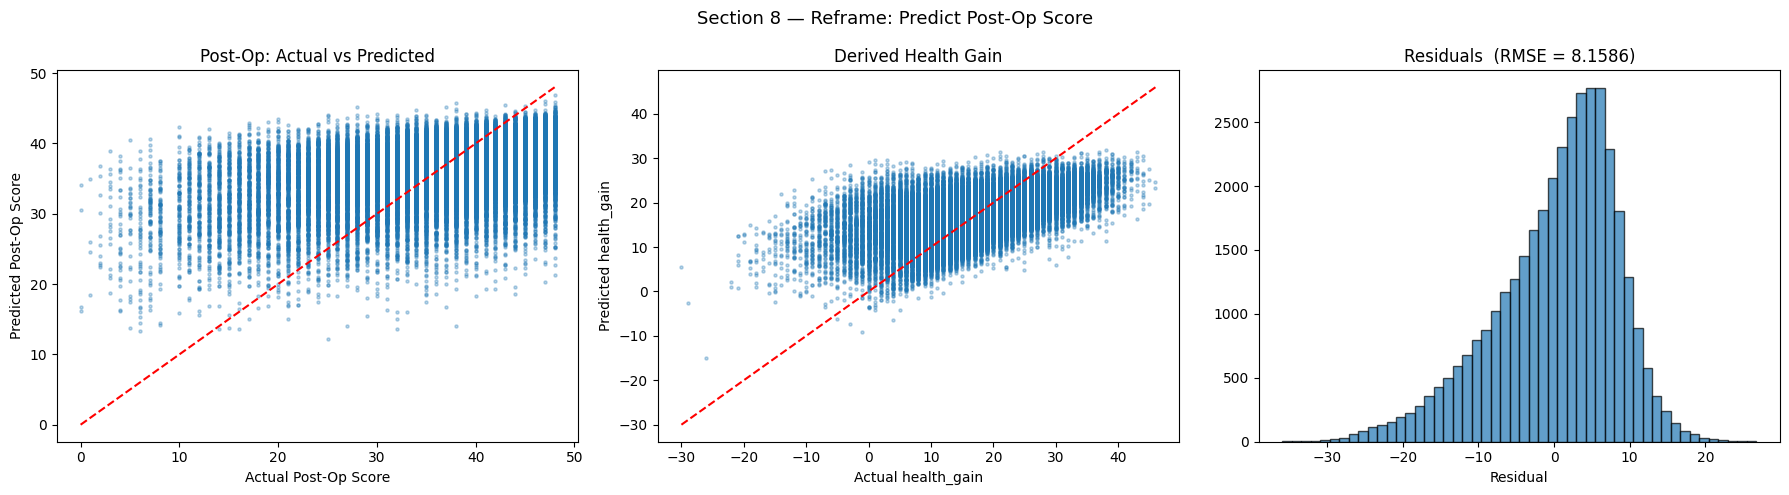

Residual stats: mean=0.2740  std=8.1540


In [11]:
# ── Diagnostic plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Section 8 — Reframe: Predict Post-Op Score', fontsize=13)

axes[0].scatter(y_s8_te, y_pred_postop, alpha=0.3, s=5)
axes[0].plot([0, 48], [0, 48], 'r--')
axes[0].set_xlabel('Actual Post-Op Score')
axes[0].set_ylabel('Predicted Post-Op Score')
axes[0].set_title('Post-Op: Actual vs Predicted')

axes[1].scatter(actual_hg_s8, predicted_hg, alpha=0.3, s=5)
lims = [min(actual_hg_s8.min(), predicted_hg.min()),
        max(actual_hg_s8.max(), predicted_hg.max())]
axes[1].plot(lims, lims, 'r--')
axes[1].set_xlabel('Actual health_gain')
axes[1].set_ylabel('Predicted health_gain')
axes[1].set_title('Derived Health Gain')

resid_s8 = actual_hg_s8 - predicted_hg
axes[2].hist(resid_s8, bins=50, edgecolor='k', alpha=0.7)
axes[2].set_title(f'Residuals  (RMSE = {test_rmse_s8:.4f})')
axes[2].set_xlabel('Residual')

plt.tight_layout()
plt.show()
print(f'Residual stats: mean={resid_s8.mean():.4f}  std={resid_s8.std():.4f}')
